# NEXT-100 - Toy MC - 4bar 

Test with Toy MC Kr smample with 'realistic' parameters

Check that the algorithms works with true MC


JA Hernando, 25/02/07

In [2]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

## Configuration

In [3]:
import re
import glob
from collections import namedtuple

import sys
pypaths= ("/Users/hernando/work/investigacion/NEXT/software/nextana",
         "/Users/hernando/work/investigacion/NEXT/software/hipy",
         "/Users/hernando/work/investigacion/NEXT/software/IC")
for ipypath in pypaths:
       sys.path.insert(0,ipypath)

In [4]:
import numpy             as np
import pandas            as pd
import tables            as tb
from   scipy             import stats
from   scipy             import optimize

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import axes3d

plt.rcParams['image.cmap'] = 'rainbow'

In [5]:
from invisible_cities.io.dst_io import load_dst, load_dsts

In [6]:
import hipy.utils        as ut
import hipy.pltext       as pltext
import hipy.profile      as prof

import nana.kr.krana    as krana
import nana.kr.krmap    as krtool

#import nana.bclouds.bclouds      as bc
#import hipy.hfit         as hfit
from invisible_cities.io.dst_io import load_dst, load_dsts
#import invisible_cities.io.dst_io as dio

In [7]:
pltext.style()

import warnings
warnings.filterwarnings('ignore')

import time
print(' Last revision ', time.asctime())

 Last revision  Thu Feb  6 15:56:16 2025


## Generate

In [102]:
n   = 1000000
e0  = 17e3 # pes
tau = 50e3 # ms
length = 1400 # ms
width =   900 # mm
df = krtool.generate_kr_toy(n, length, width = width, e0 = e0, tau = tau)

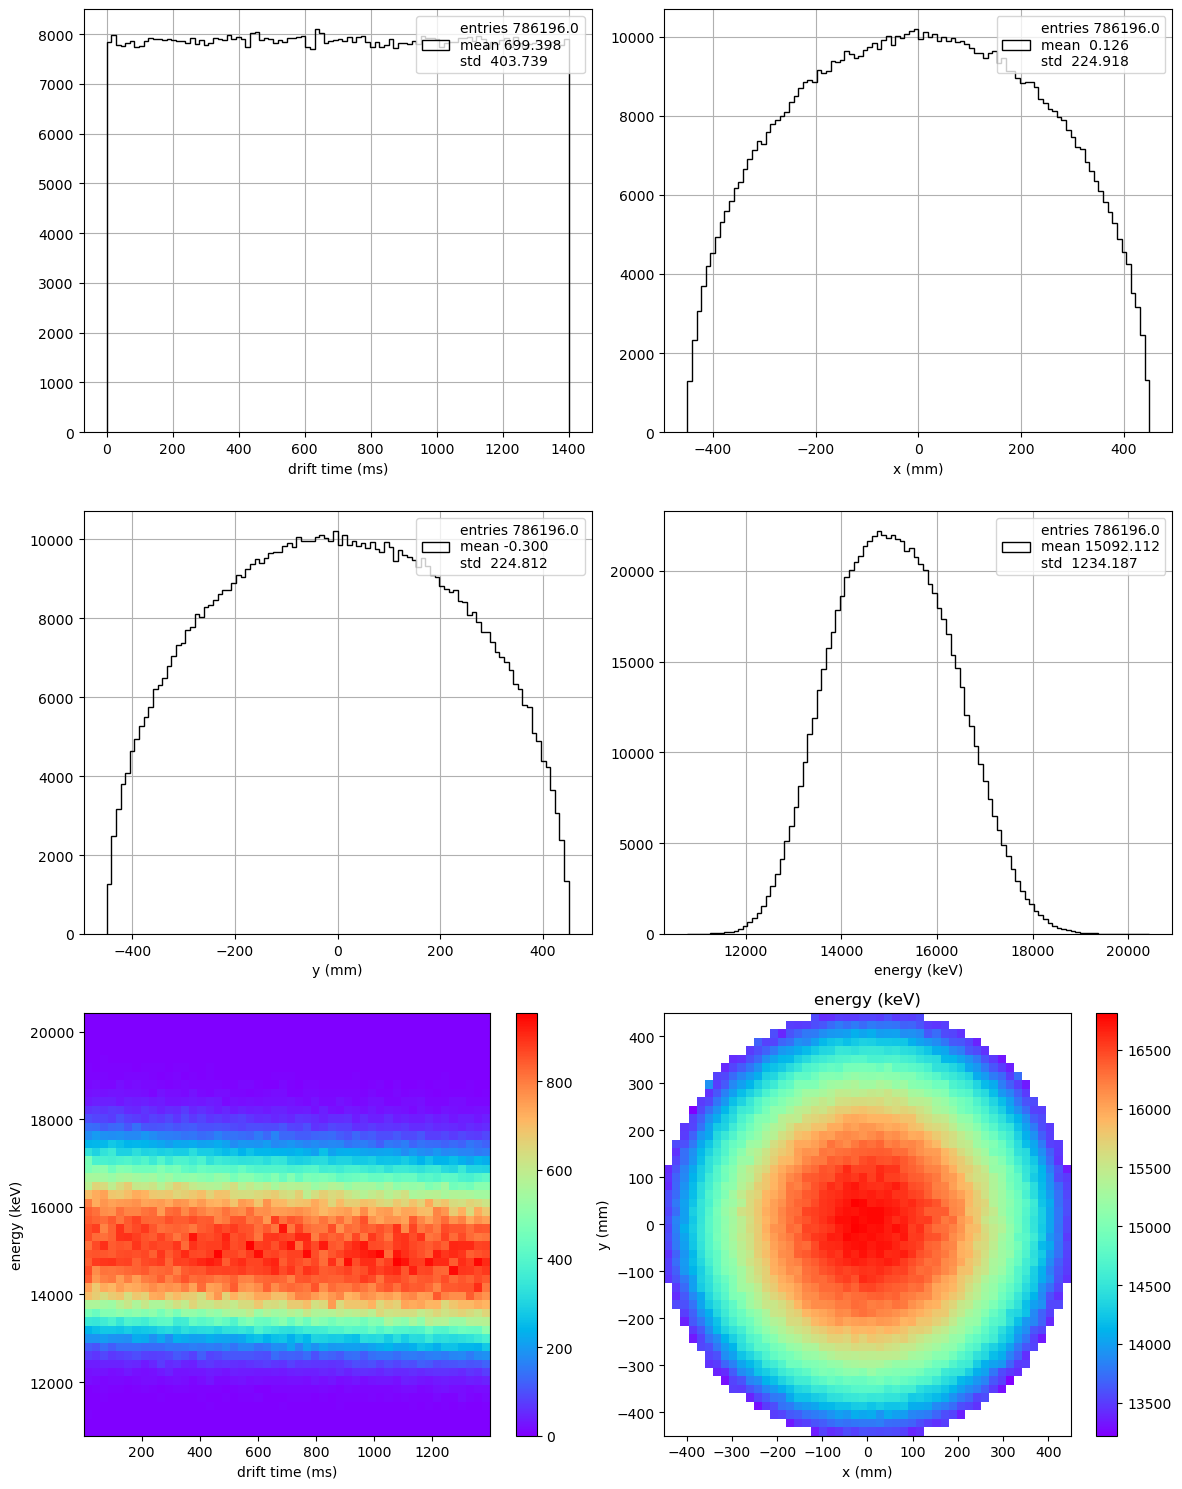

In [103]:
krtool.plot_kr_data(df, 50)

## Kr map

In [105]:
krmap, residuals   = krtool.krmap(coors, dtime, energy, bins = bins, counts_min = counts_min, dt0 = 0)

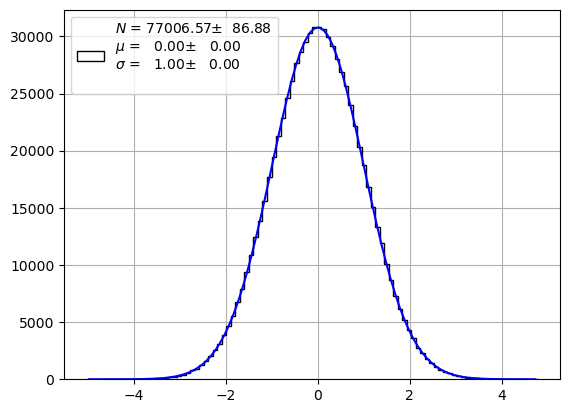

In [115]:
xsel = ~np.isnan(residuals)
residuals = residuals[xsel]
pltext.hfit(residuals, 100, fun = 'gaus');

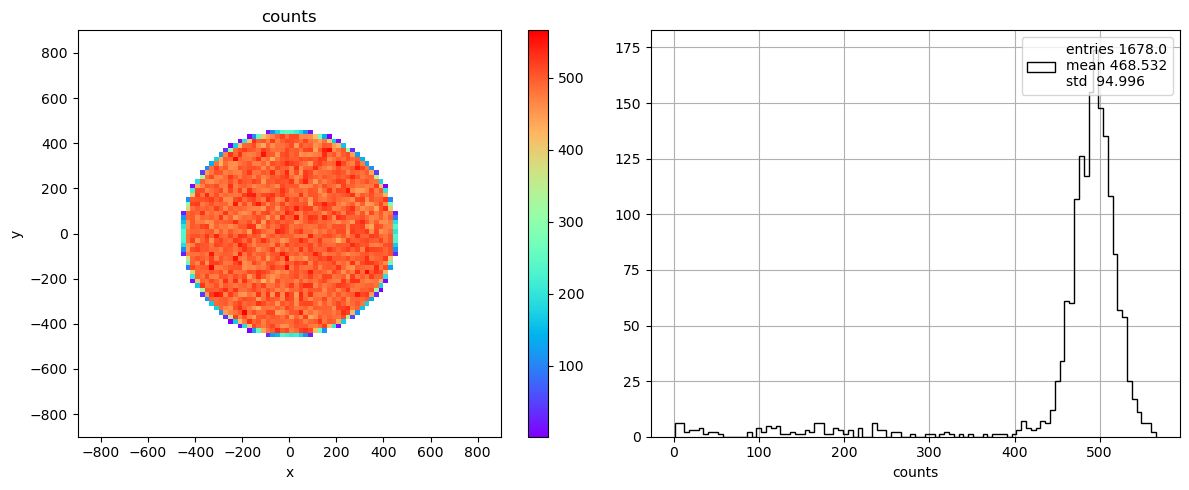

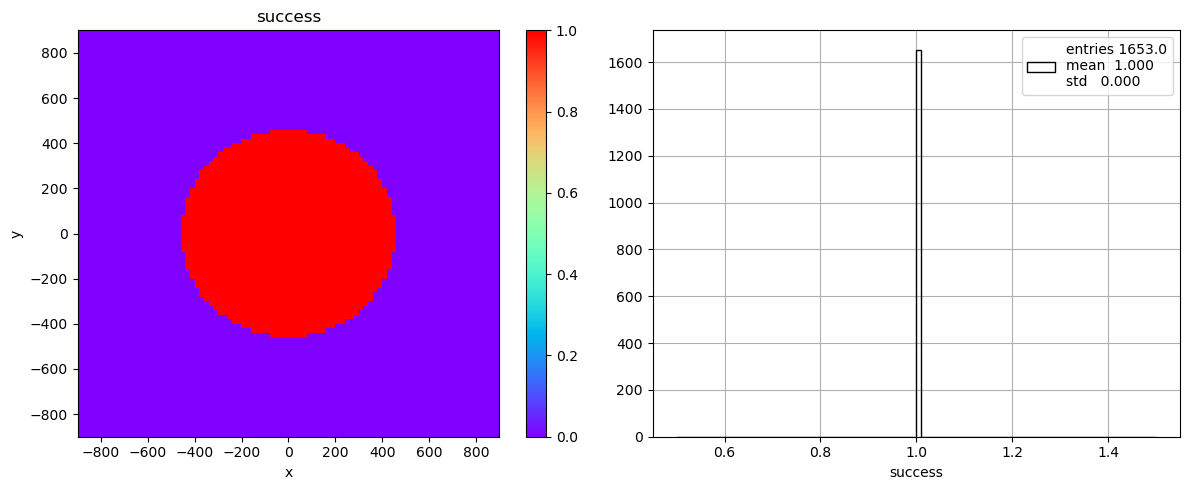

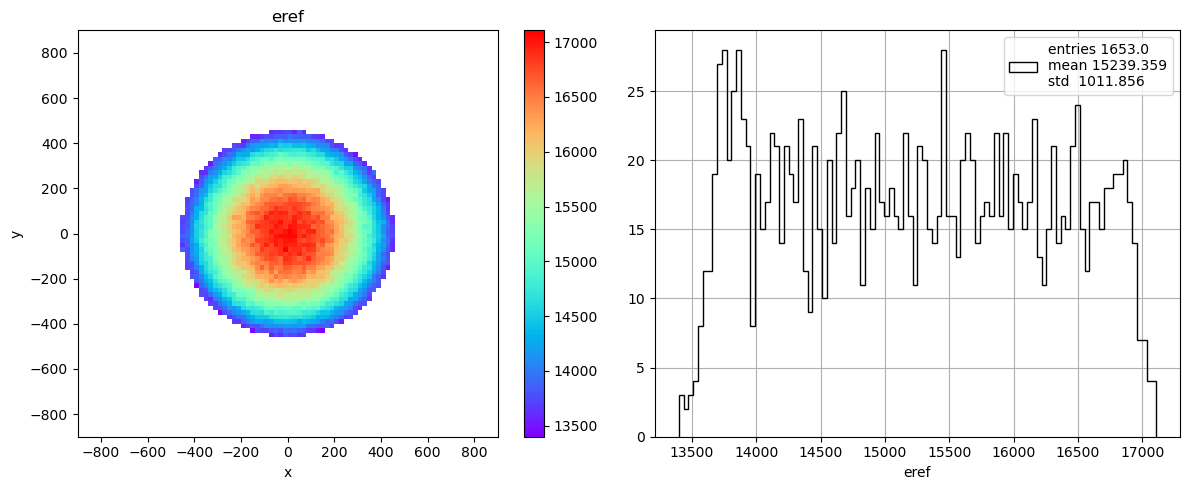

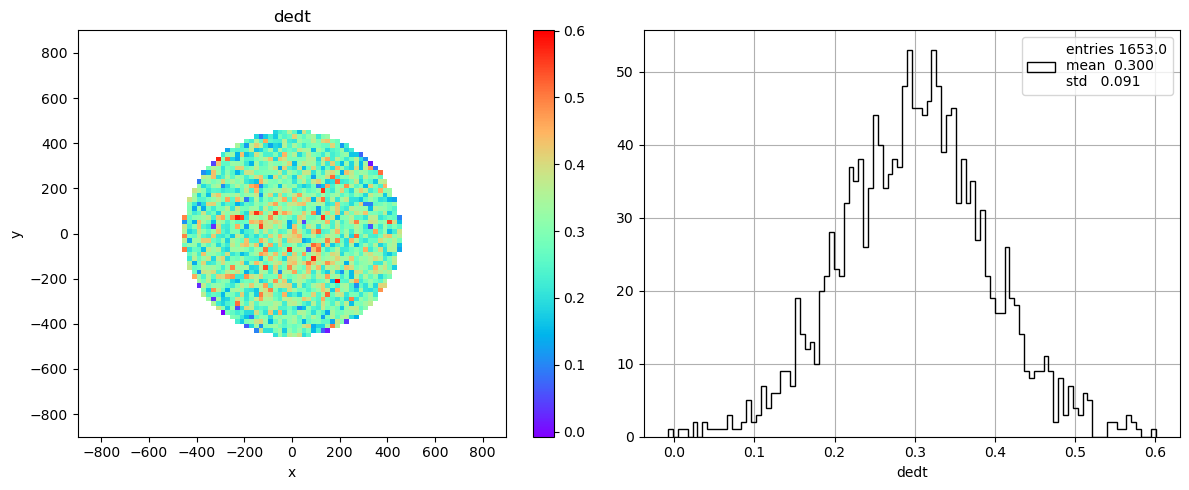

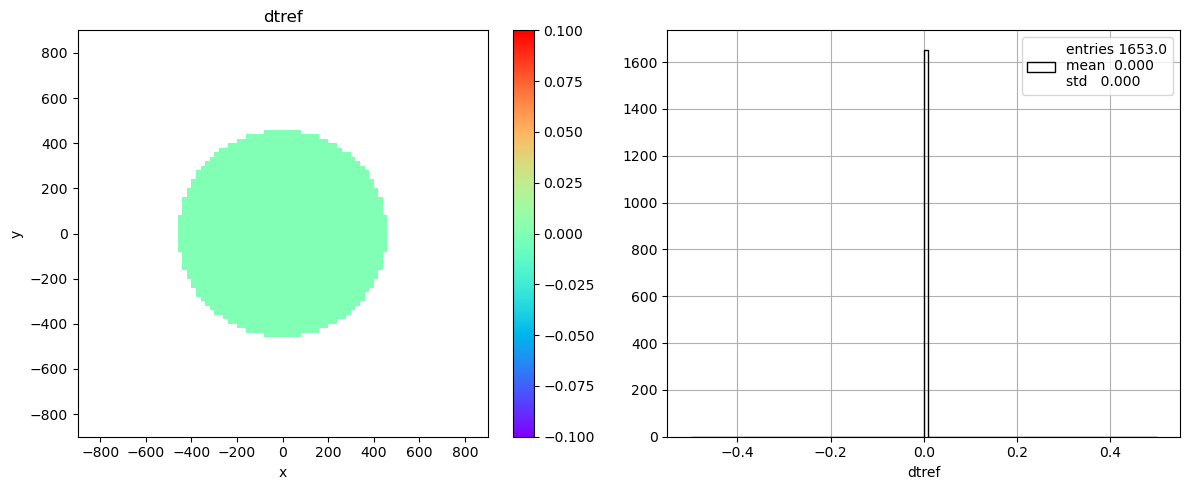

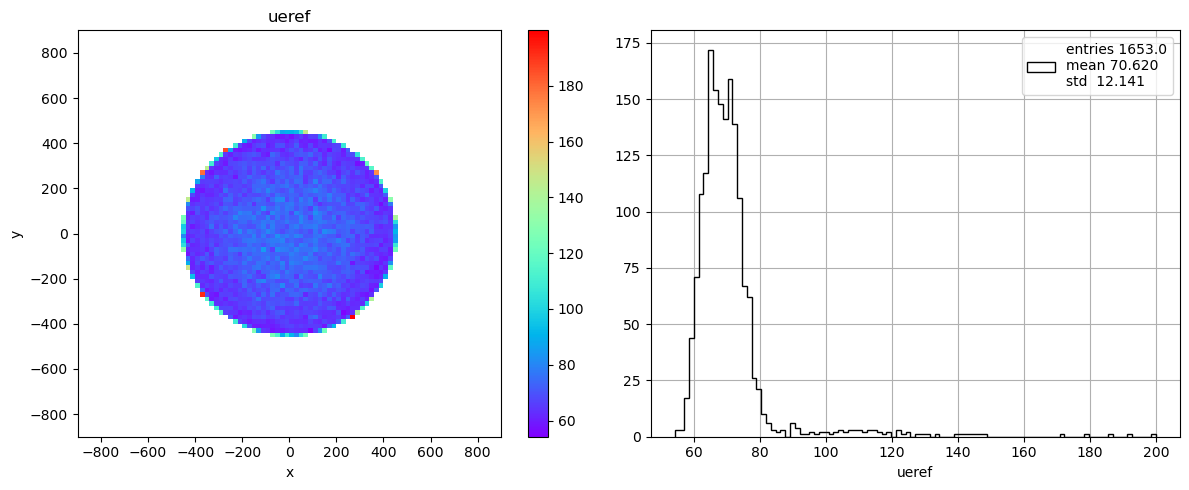

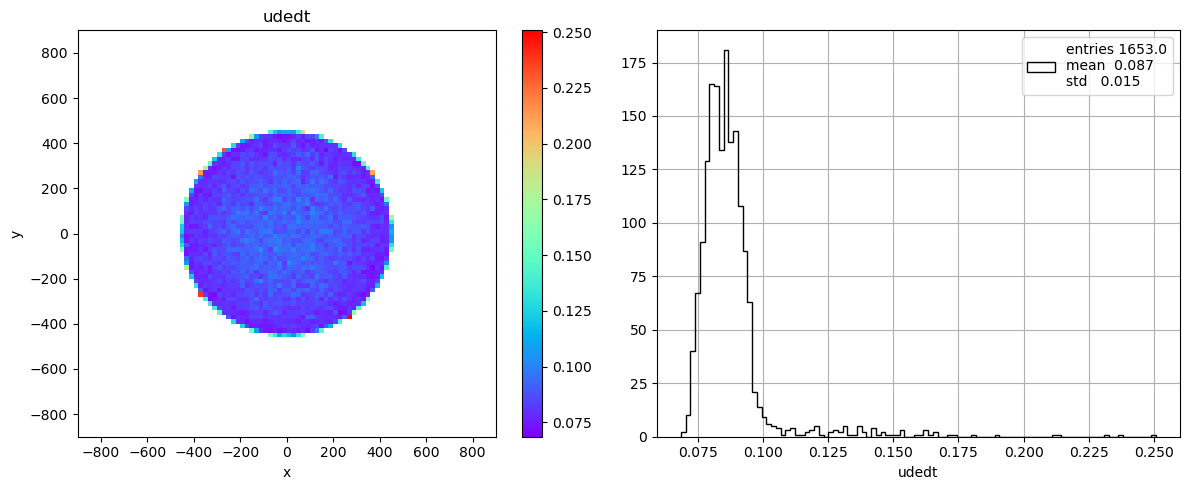

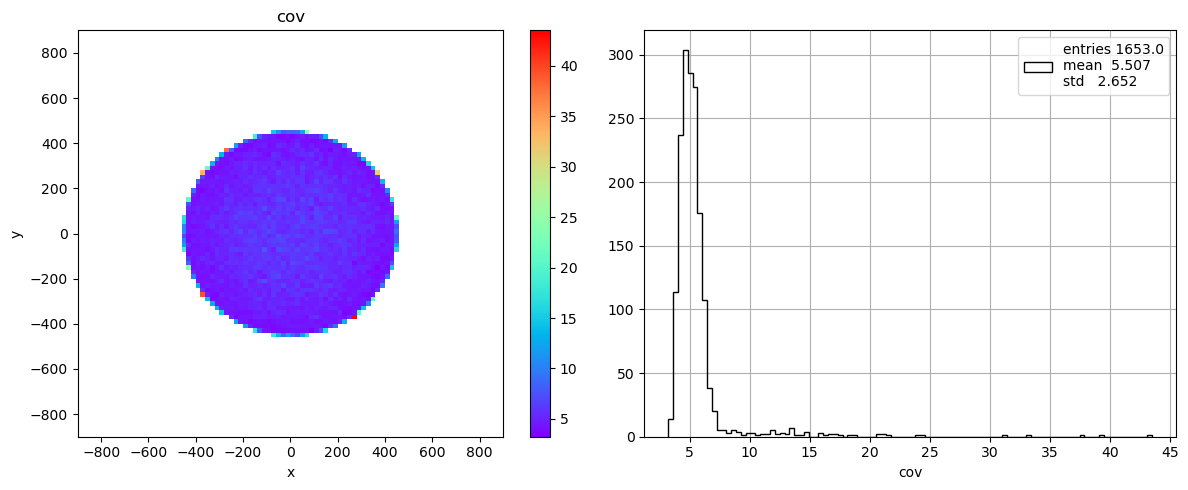

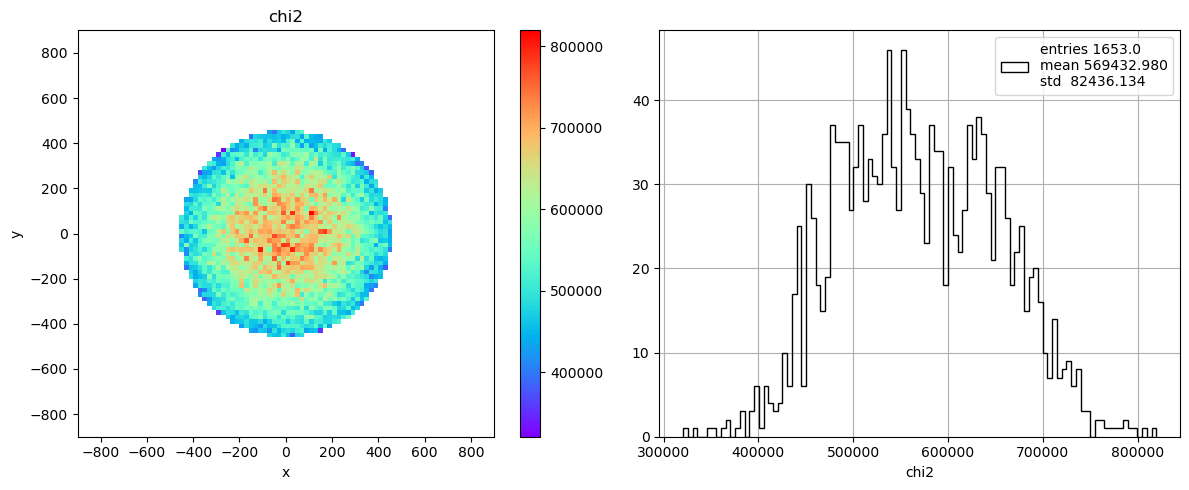

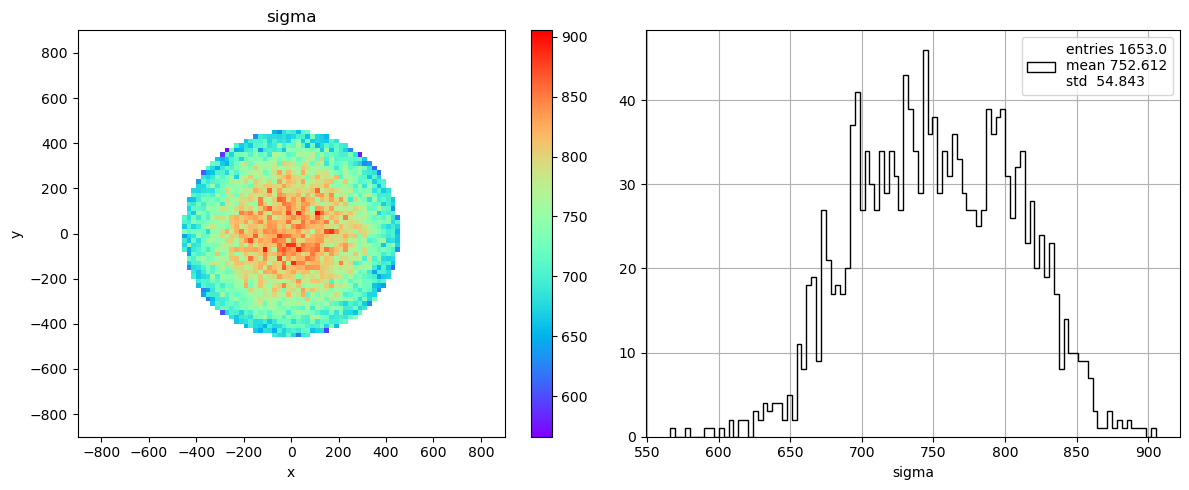

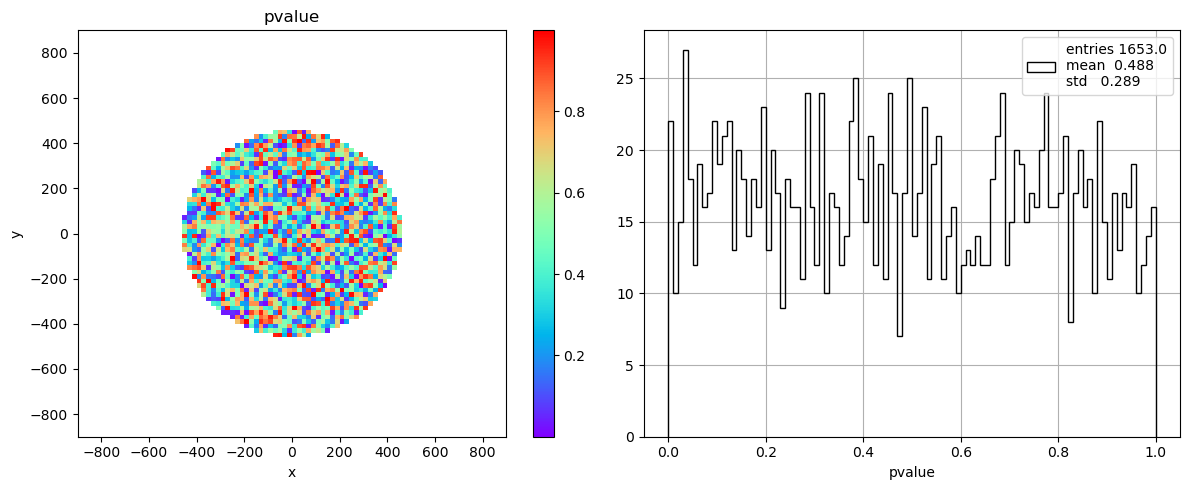

In [106]:
krtool.plot_xyvar(krmap.counts , krmap.bin_edges, 'counts' , mask = krmap.counts > 0)
krtool.plot_xyvar(krmap.success, krmap.bin_edges, 'success', mask = krmap.success)
krtool.plot_xyvar(krmap.eref   , krmap.bin_edges, 'eref'   , mask = krmap.success)
krtool.plot_xyvar(krmap.dedt   , krmap.bin_edges, 'dedt'   , mask = krmap.success)
krtool.plot_xyvar(krmap.dtref  , krmap.bin_edges, 'dtref'  , mask = krmap.success)
krtool.plot_xyvar(krmap.ueref  , krmap.bin_edges, 'ueref'  , mask = krmap.success)
krtool.plot_xyvar(krmap.udedt  , krmap.bin_edges, 'udedt'  , mask = krmap.success)
krtool.plot_xyvar(krmap.cov    , krmap.bin_edges, 'cov'    , mask = krmap.success)
krtool.plot_xyvar(krmap.chi2   , krmap.bin_edges, 'chi2'   , mask = krmap.success)
krtool.plot_xyvar(krmap.sigma  , krmap.bin_edges, 'sigma'  , mask = krmap.success)
krtool.plot_xyvar(krmap.pvalue , krmap.bin_edges, 'pvalue' , mask = krmap.success)

## Correction

In [107]:
corr_energy = krtool.krmap_scale(coors, dtime, energy, krmap, scale = 41.5)

 Resolution  11.78 % FWHM


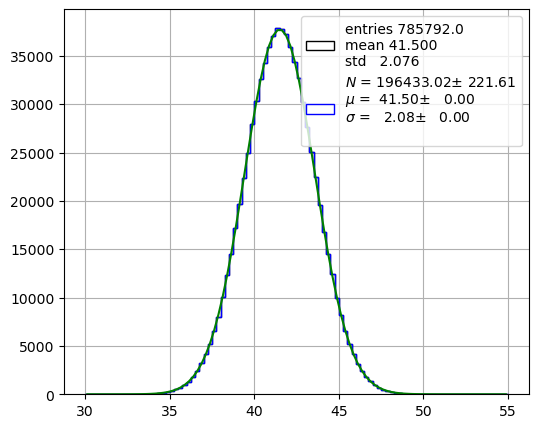

In [110]:
xsel = ~np.isnan(corr_energy)
nbins, erange = 100, (30., 55)
pltext.canvas(1, 1);
pltext.hist(corr_energy[xsel], nbins, erange);
cc = pltext.hfit(corr_energy[xsel], nbins, range = erange, fun = 'gaus');
pars = cc[3]
resolution = 235.5 * pars[2]/pars[1]
print(' Resolution {:6.2f} % FWHM'.format(resolution))

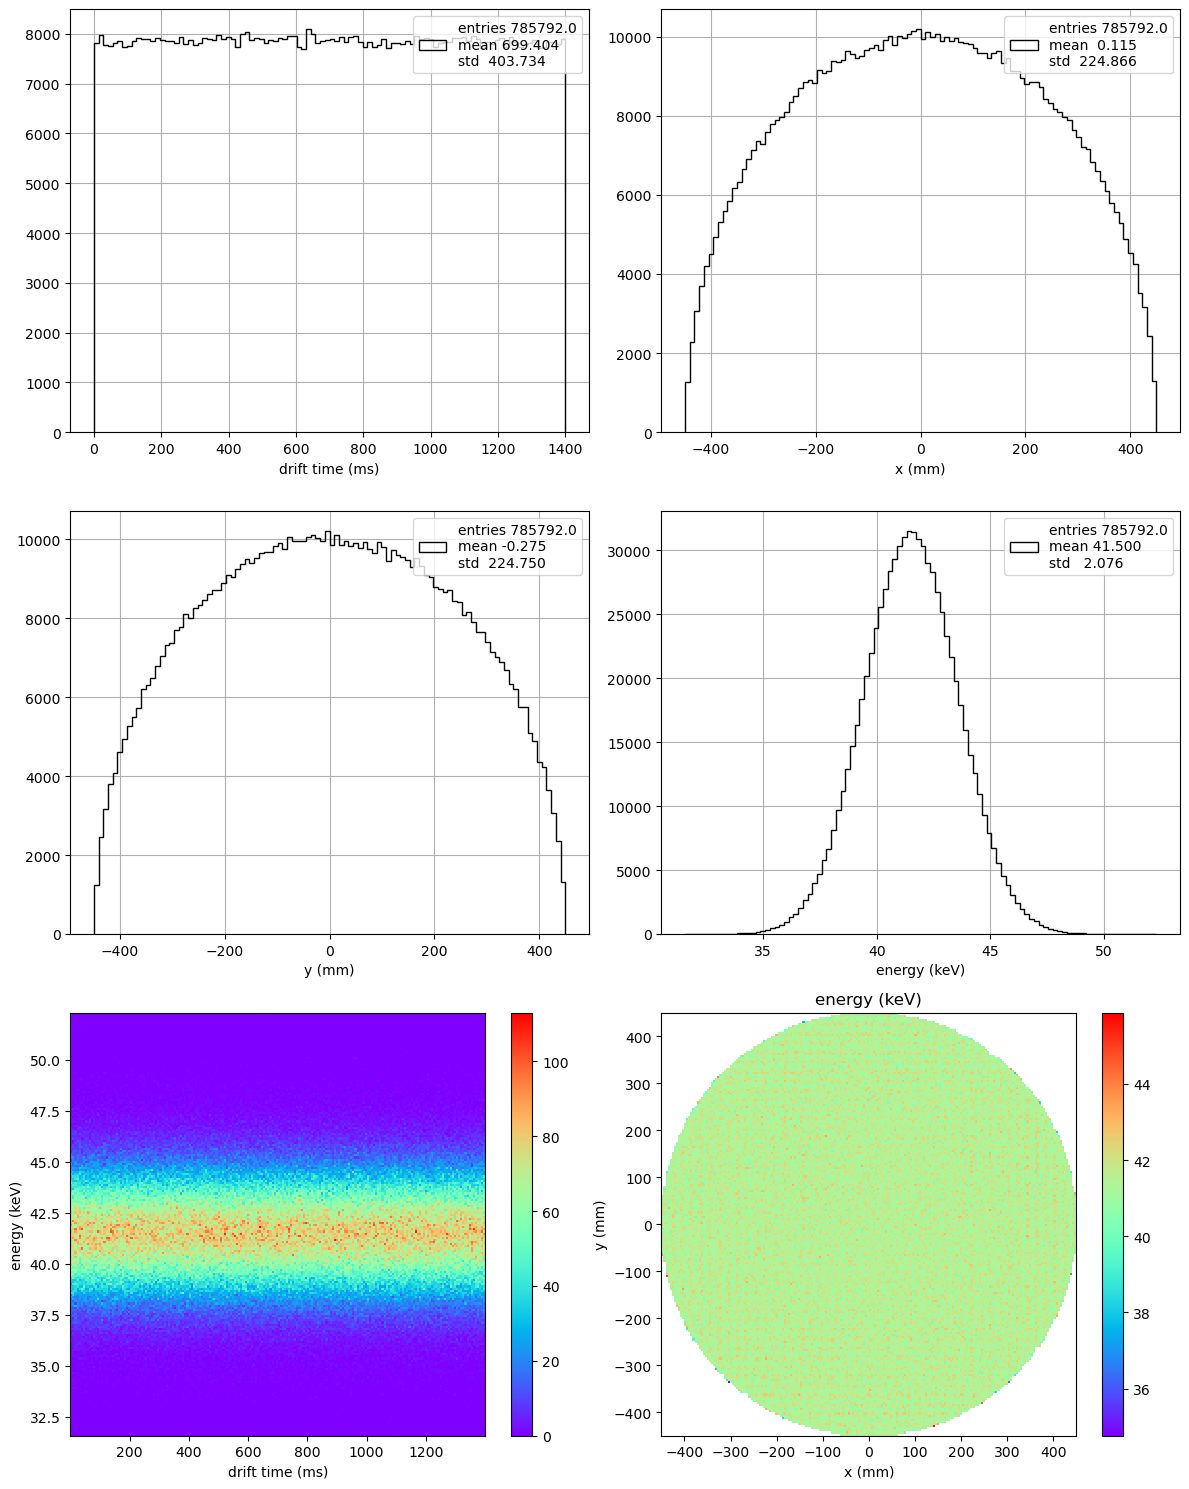

In [111]:
xsel = ~np.isnan(corr_energy)
df = {'x': coors[0][xsel], 'y' : coors[1][xsel], 'dtime': dtime[xsel], 'energy' : corr_energy[xsel]}
df = pd.DataFrame(df)
krana.plot_data(df, bins = 200)

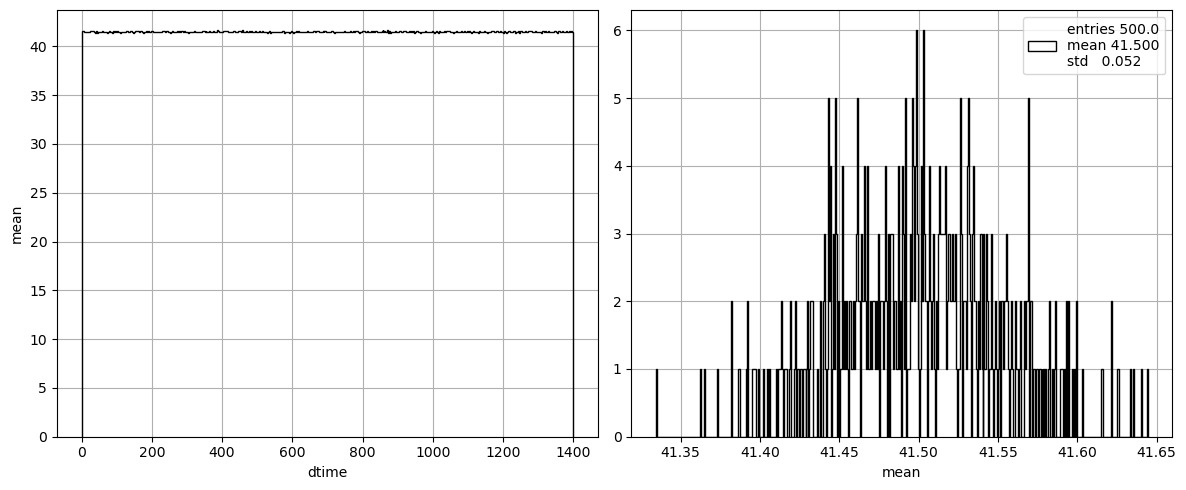

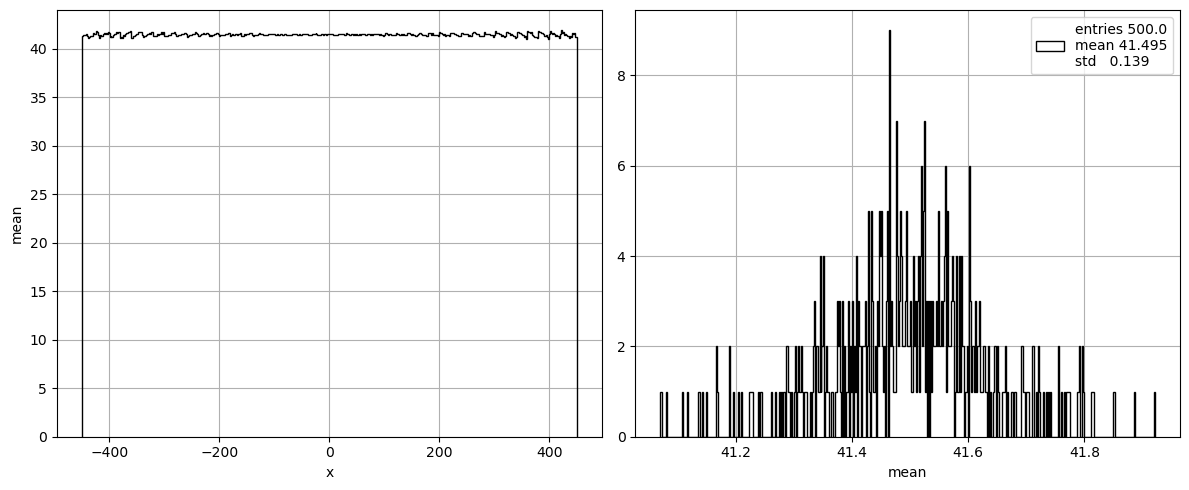

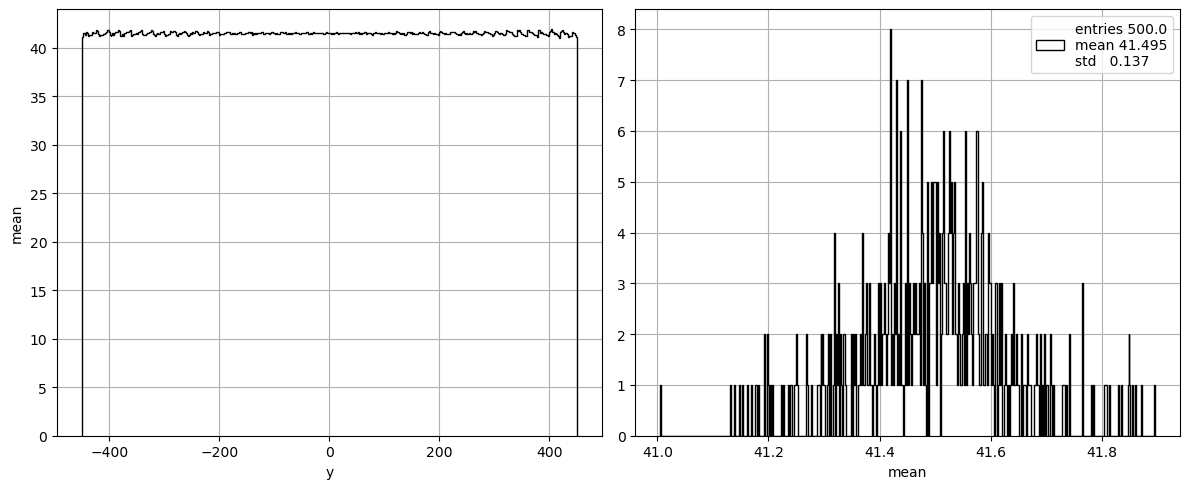

In [112]:
krtool.plot_xydt_energy_profiles(df, nbins = 500)


## Charge